# 09 — Camera Captured Eye Dataset Analysis

This notebook **only analyzes** `dataset/Camera captured eye Dataset`.

It does **not**:
- modify `efficientnetv2_b0_4class_best.keras`
- retrain the 4-class disease model
- modify the existing 5885-image fundus dataset
- change backend or frontend code
- train YOLO

**Existing 4-class fundus mapping (unchanged, for comparison only):**
`0` Normal · `1` Cataract · `2` Diabetic Retinopathy · `3` Glaucoma


In [1]:
# STEP 1 — Imports and paths
from __future__ import annotations

import csv
import hashlib
import json
import math
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image, ImageDraw, ImageFont, UnidentifiedImageError

PROJECT_ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path(r"D:/Practice Projects/Disease Detection"),
]
PROJECT_ROOT = next((p for p in PROJECT_ROOT_CANDIDATES if (p / "dataset").exists() and (p / "preprocessing").exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate project root.")

CAMERA_ROOT = PROJECT_ROOT / "dataset" / "Camera captured eye Dataset"
EXISTING_META = PROJECT_ROOT / "preprocessing" / "dataset_metadata_v2.csv"
SPLIT_DIR = PROJECT_ROOT / "preprocessing" / "splits_v2"
REPORTS_DIR = PROJECT_ROOT / "reports"
PREVIEW_DIR = REPORTS_DIR / "camera_dataset_analysis" / "previews"
PREVIEW_DIR.mkdir(parents=True, exist_ok=True)

SPLITS = ("train", "val", "test")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

print("PROJECT_ROOT:", PROJECT_ROOT)
print("CAMERA_ROOT:", CAMERA_ROOT)
print("CAMERA_ROOT exists:", CAMERA_ROOT.exists())


PROJECT_ROOT: d:\Practice Projects\Disease Detection
CAMERA_ROOT: d:\Practice Projects\Disease Detection\dataset\Camera captured eye Dataset
CAMERA_ROOT exists: True


In [2]:
# STEP 2 — Dataset structure
def list_tree(root: Path, max_depth: int = 2) -> list[str]:
    lines = []
    for path in sorted(root.rglob("*")):
        rel = path.relative_to(root)
        if len(rel.parts) > max_depth:
            continue
        kind = "dir" if path.is_dir() else "file"
        extra = ""
        if path.is_dir():
            extra = f"  ({sum(1 for p in path.iterdir() if p.is_file())} files)"
        elif path.is_file() and path.suffix.lower() in {".yaml", ".yml", ".json", ".md", ".txt", ".csv", ".cache"}:
            extra = f"  ({path.stat().st_size} bytes)"
        lines.append(f"{kind:4} {rel.as_posix()}{extra}")
    return lines

structure_lines = list_tree(CAMERA_ROOT, max_depth=3)
print("Top-level entries:")
for p in sorted(CAMERA_ROOT.iterdir()):
    print(" ", "DIR " if p.is_dir() else "FILE", p.name)

print("\nConfig / documentation files (yaml, yml, json, md, readme, names):")
config_files = [
    p for p in CAMERA_ROOT.rglob("*")
    if p.is_file()
    and (
        p.suffix.lower() in {".yaml", ".yml", ".json", ".md", ".csv", ".names"}
        or p.name.lower().startswith("readme")
        or p.name.lower() in {"data.yaml", "data.yml", "classes.txt", "notes.json"}
    )
]
if config_files:
    for p in config_files:
        print(" ", p.relative_to(CAMERA_ROOT))
else:
    print("  NONE FOUND (no data.yaml / README / class-names file in this copy)")

print("\nFolder tree (depth <= 3):")
print("\n".join(structure_lines[:80]))
print(f"... {len(structure_lines)} listed paths")


Top-level entries:
  DIR  test
  DIR  train
  DIR  val

Config / documentation files (yaml, yml, json, md, readme, names):
  NONE FOUND (no data.yaml / README / class-names file in this copy)

Folder tree (depth <= 3):
dir  test  (1 files)
dir  test/images  (198 files)
file test/images/i_1017_jpg.rf.2e27af2fc6fe82cbf69299739170e904.jpg
file test/images/i_1019_jpg.rf.0fdbde19c25d9c8990f1dbe6c1b60baa.jpg
file test/images/i_101_jpg.rf.5acaaba095b51582aa7e7cdf44e30f01.jpg
file test/images/i_1024_jpg.rf.93f2013f96f8aee4793208c0412abef9.jpg
file test/images/i_1032_jpg.rf.8ab16ca807bc1cb4c0f5918d6b7a96ef.jpg
file test/images/i_1033_jpg.rf.e8e42b31a9f17976effc7a41fde3dea1.jpg
file test/images/i_1057_jpg.rf.201596b4c67ea16f6a5d386409630884.jpg
file test/images/i_1060_jpg.rf.77f266739ab8b2fd3afe10d654ffbf47.jpg
file test/images/i_1063_jpg.rf.dd5f7d1cc75e22c69123114b10fd35c2.jpg
file test/images/i_1065_jpg.rf.73c38cc41d68fb6d2f64b48cf3f3ca3b.jpg
file test/images/i_1076_jpg.rf.d1417d69f9bd40c191c2

In [3]:
# STEP 3 — Inventory images + YOLO labels
def parse_yolo_label(path: Path) -> dict:
    raw = path.read_text(encoding="utf-8", errors="replace")
    rows = []
    issues = []
    for i, line in enumerate(raw.splitlines(), start=1):
        if not line.strip():
            continue
        parts = line.split()
        if len(parts) < 5:
            issues.append(f"line {i}: expected >=5 fields, got {len(parts)}")
            continue
        try:
            cid = int(float(parts[0]))
            xc, yc, bw, bh = (float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4]))
        except ValueError:
            issues.append(f"line {i}: non-numeric YOLO fields")
            continue
        yolo_ok = (
            cid >= 0
            and 0.0 <= xc <= 1.0
            and 0.0 <= yc <= 1.0
            and 0.0 < bw <= 1.0
            and 0.0 < bh <= 1.0
        )
        if not yolo_ok:
            issues.append(f"line {i}: values outside YOLO normalized range or invalid class")
        rows.append({"class_id": cid, "xc": xc, "yc": yc, "bw": bw, "bh": bh, "yolo_ok": yolo_ok})
    return {"rows": rows, "issues": issues, "raw_empty": not bool(rows)}


records = []
unmatched_labels = []
unmatched_images = []
class_id_counter = Counter()
box_counter = Counter()

for split in SPLITS:
    img_dir = CAMERA_ROOT / split / "images"
    lab_dir = CAMERA_ROOT / split / "labels"
    images = {p.stem: p for p in img_dir.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS | {".jpg"}}
    labels = {p.stem: p for p in lab_dir.iterdir() if p.suffix.lower() == ".txt"}
    for stem, img_path in images.items():
        lab_path = labels.pop(stem, None)
        rec = {
            "split": split,
            "stem": stem,
            "image_path": str(img_path),
            "filename": img_path.name,
            "label_path": str(lab_path) if lab_path else None,
            "has_label": lab_path is not None,
        }
        if lab_path is None:
            rec.update({"n_boxes": 0, "class_ids": [], "yolo_valid": False, "label_issues": ["missing label file"]})
            unmatched_images.append(rec)
        else:
            parsed = parse_yolo_label(lab_path)
            ids = [r["class_id"] for r in parsed["rows"]]
            rec.update({
                "n_boxes": len(parsed["rows"]),
                "class_ids": ids,
                "primary_class": ids[0] if ids else None,
                "unique_classes": sorted(set(ids)),
                "yolo_valid": bool(parsed["rows"]) and all(r["yolo_ok"] for r in parsed["rows"]) and not parsed["issues"],
                "label_issues": parsed["issues"],
                "boxes": parsed["rows"],
            })
            for cid in ids:
                class_id_counter[cid] += 1
            box_counter[len(ids)] += 1
        records.append(rec)
    for stem, lab_path in labels.items():
        unmatched_labels.append({"split": split, "label": lab_path.name})

print("Images per split:")
for split in SPLITS:
    n_img = sum(1 for r in records if r["split"] == split)
    n_lab = sum(1 for r in records if r["split"] == split and r["has_label"])
    print(f"  {split:5} images={n_img:4d}  labels_matched={n_lab:4d}")
print("TOTAL images:", len(records))
print("Images missing labels:", len(unmatched_images))
print("Labels missing images:", len(unmatched_labels))
print("Boxes per image:", dict(box_counter))
print("Class-id box counts:", dict(sorted(class_id_counter.items())))


Images per split:
  train images=1385  labels_matched=1385
  val   images= 396  labels_matched= 396
  test  images= 198  labels_matched= 198
TOTAL images: 1979
Images missing labels: 0
Labels missing images: 0
Boxes per image: {1: 1974, 2: 5}
Class-id box counts: {0: 1719, 1: 265}


In [4]:
# STEP 4 — What class 0 and class 1 are (evidence, not guesses)
print("=== Evidence search for class names ===")
print("1. data.yaml / README / classes.txt / notes.json:", "ABSENT" if not config_files else config_files)

# Ultralytics labels.cache (from a previous YOLO run on another machine)
cache_meta = {}
for split in SPLITS:
    cache_path = CAMERA_ROOT / split / "labels.cache"
    if not cache_path.exists():
        continue
    cache = np.load(cache_path, allow_pickle=True).item()
    cache_meta[split] = {
        "version": cache.get("version"),
        "results": list(cache.get("results") or []),
        "n_indexed_labels": len(cache.get("labels") or []),
        "n_msgs": len(cache.get("msgs") or []),
        "sample_im_file": (cache.get("labels") or [{}])[0].get("im_file") if cache.get("labels") else None,
        "class1_exceeds_nc1_msgs": sum("class count 1" in str(m) or "Possible class labels are 0-0" in str(m) for m in cache.get("msgs") or []),
    }
    print(f"\n2. {split}/labels.cache")
    print("   version:", cache_meta[split]["version"])
    print("   results tuple (nf, nm, ne, nc, n):", cache_meta[split]["results"])
    print("   indexed labels:", cache_meta[split]["n_indexed_labels"], "warning msgs:", cache_meta[split]["n_msgs"])
    print("   original im_file sample:", cache_meta[split]["sample_im_file"])
    print("   msgs saying class 1 exceeds nc=1:", cache_meta[split]["class1_exceeds_nc1_msgs"])

print("\n3. Unique class IDs in *.txt labels:", sorted(class_id_counter))
print("   YOLO line format observed: class_id x_center y_center width height (normalized 0-1)")

# Filename families vs class id
def family(name: str) -> str:
    n = name.lower()
    if n.startswith("photo-"):
        return "PHOTO-YYYY-MM-DD (WhatsApp/camera timestamp)"
    if n.startswith("i_"):
        return "i_* (sequential crop names)"
    if n.startswith("image_"):
        return "image_* (Roboflow-renamed PNG sources)"
    return "other"

family_class = defaultdict(Counter)
for rec in records:
    for cid in rec.get("class_ids") or []:
        family_class[family(rec["filename"])][int(cid)] += 1
print("\n4. Class IDs by filename family (box counts):")
for fam, ctr in family_class.items():
    print("  ", fam, dict(ctr))

print(
    "\nInterpretation constraint: this copy has NO names: list. "
    "Class meaning must come from label integers + the pixels inside the boxes."
)


=== Evidence search for class names ===
1. data.yaml / README / classes.txt / notes.json: ABSENT

2. train/labels.cache
   version: 1.0.3
   results tuple (nf, nm, ne, nc, n): [1385, 0, 0, 197, 1385]
   indexed labels: 1188 warning msgs: 197
   original im_file sample: C:\Users\KIIT\Desktop\ELI_DEMO\ROBO_FLOW\split_dataset\train\images\PHOTO-2023-07-27-12-08-36_jpg.rf.5e2b7aae13bde64a4613048f6b1a8aef.jpg
   msgs saying class 1 exceeds nc=1: 197

2. val/labels.cache
   version: 1.0.3
   results tuple (nf, nm, ne, nc, n): [396, 0, 0, 38, 396]
   indexed labels: 358 warning msgs: 38
   original im_file sample: C:\Users\KIIT\Desktop\ELI_DEMO\ROBO_FLOW\split_dataset\val\images\PHOTO-2023-07-27-12-41-26_jpg.rf.0c54af79d765c863475f99265175fc10.jpg
   msgs saying class 1 exceeds nc=1: 38

2. test/labels.cache
   version: 1.0.3
   results tuple (nf, nm, ne, nc, n): [198, 0, 0, 29, 198]
   indexed labels: 169 warning msgs: 29
   original im_file sample: C:\Users\KIIT\Desktop\ELI_DEMO\ROBO_FLOW\s

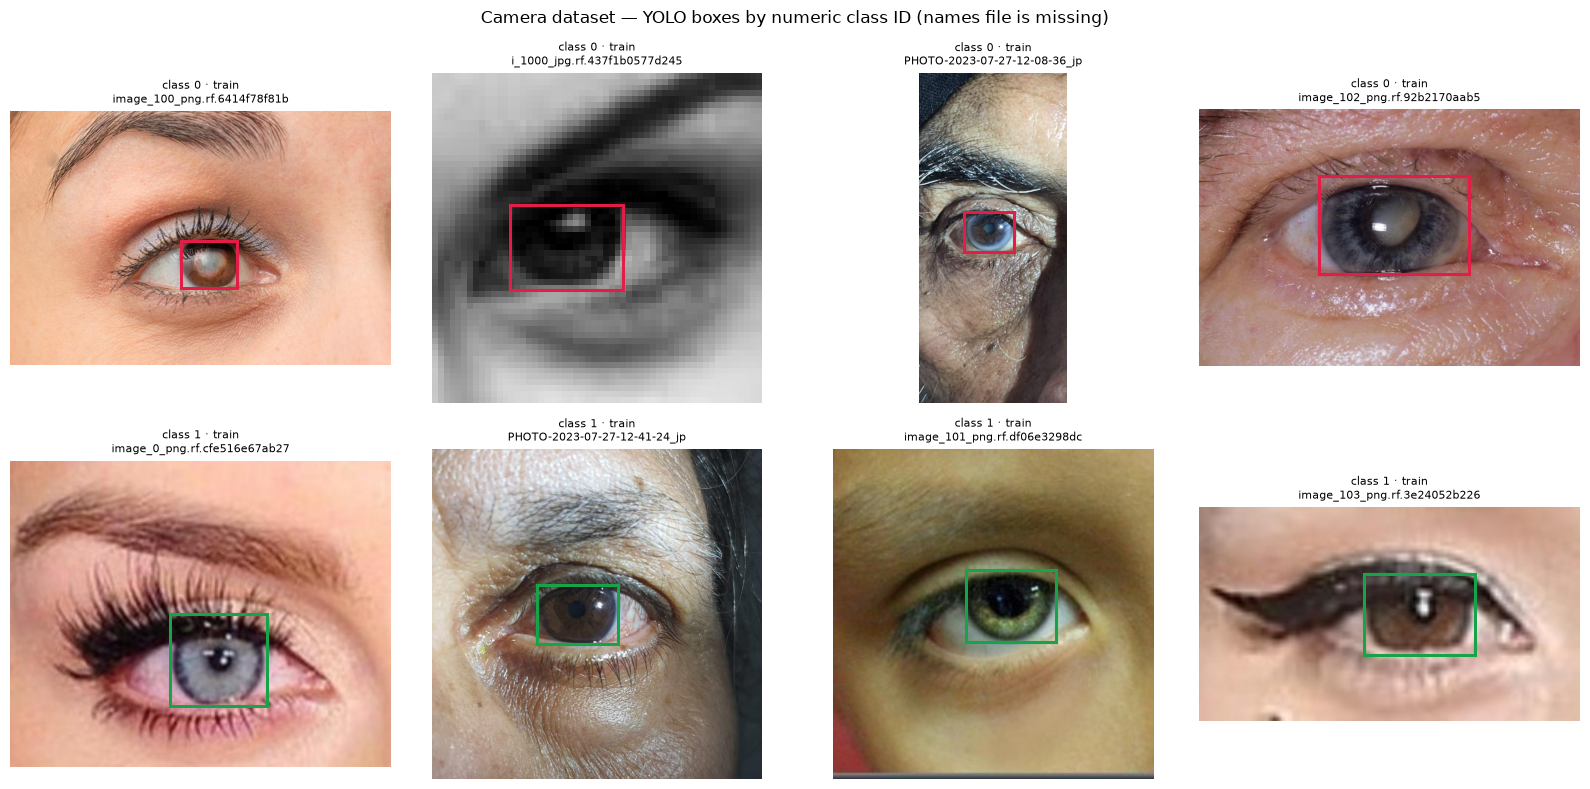

Saved previews to d:\Practice Projects\Disease Detection\reports\camera_dataset_analysis\previews


In [5]:
# STEP 5 — Representative images with bounding boxes
CLASS_COLORS = {0: "#e11d48", 1: "#16a34a"}


def yolo_to_xyxy(box, width, height):
    xc, yc, bw, bh = box["xc"], box["yc"], box["bw"], box["bh"]
    x1 = (xc - bw / 2) * width
    y1 = (yc - bh / 2) * height
    x2 = (xc + bw / 2) * width
    y2 = (yc + bh / 2) * height
    return x1, y1, x2, y2


def pick_examples(class_id: int, n: int = 4) -> list[dict]:
    chosen = []
    # prefer single-class images, mix filename families
    pool = [r for r in records if r.get("unique_classes") == [class_id] and r.get("boxes")]
    by_fam = defaultdict(list)
    for rec in pool:
        by_fam[family(rec["filename"])].append(rec)
    for fam in by_fam:
        if len(chosen) >= n:
            break
        chosen.append(by_fam[fam][0])
    for rec in pool:
        if len(chosen) >= n:
            break
        if rec not in chosen:
            chosen.append(rec)
    return chosen[:n]


preview_index = []
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row_i, cid in enumerate((0, 1)):
    examples = pick_examples(cid, 4)
    for col_i in range(4):
        ax = axes[row_i][col_i]
        ax.axis("off")
        if col_i >= len(examples):
            continue
        rec = examples[col_i]
        img = Image.open(rec["image_path"]).convert("RGB")
        w, h = img.size
        ax.imshow(img)
        for box in rec["boxes"]:
            x1, y1, x2, y2 = yolo_to_xyxy(box, w, h)
            ax.add_patch(
                Rectangle(
                    (x1, y1),
                    x2 - x1,
                    y2 - y1,
                    fill=False,
                    linewidth=2.2,
                    edgecolor=CLASS_COLORS.get(cid, "yellow"),
                )
            )
        ax.set_title(f"class {cid} · {rec['split']}\n{rec['filename'][:28]}", fontsize=8)
        dest = PREVIEW_DIR / f"class{cid}_{col_i}_{rec['split']}.jpg"
        vis = img.copy()
        draw = ImageDraw.Draw(vis)
        for box in rec["boxes"]:
            x1, y1, x2, y2 = yolo_to_xyxy(box, w, h)
            color = (225, 29, 72) if cid == 0 else (22, 163, 74)
            draw.rectangle([x1, y1, x2, y2], outline=color, width=4)
            draw.text((x1 + 4, max(0, y1 - 14)), f"class {cid}", fill=color)
        vis.save(dest, quality=92)
        preview_index.append({"class_id": cid, "file": str(dest), "source": rec["filename"], "split": rec["split"]})

fig.suptitle("Camera dataset — YOLO boxes by numeric class ID (names file is missing)", fontsize=12)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "camera_dataset_analysis" / "class_previews_grid.png", dpi=140)
plt.show()
print("Saved previews to", PREVIEW_DIR)


In [6]:
# STEP 6 — Image properties, corruption check, camera-like content
readable = []
corrupt = []
format_counter = Counter()
size_counter = Counter()
aspect_buckets = Counter()

def aspect_bucket(w, h):
    ar = w / h if h else 0
    if abs(ar - 1) < 0.08:
        return "square(~1:1)"
    if ar > 1:
        return "landscape(>1)"
    return "portrait(<1)"

for rec in records:
    path = Path(rec["image_path"])
    try:
        with Image.open(path) as im:
            im.verify()
        with Image.open(path) as im:
            im = im.convert("RGB")
            w, h = im.size
            fmt = (Image.open(path).format or path.suffix.lower().lstrip(".")).upper()
            arr = np.asarray(im, dtype=np.float32)
            rec.update({
                "readable": True,
                "width": w,
                "height": h,
                "aspect_ratio": round(w / h, 4) if h else None,
                "format": fmt,
                "mode_converted": "RGB",
                "mean_r": float(arr[:, :, 0].mean()),
                "mean_g": float(arr[:, :, 1].mean()),
                "mean_b": float(arr[:, :, 2].mean()),
                "chroma": float(np.std(arr.mean(axis=2))),
                "is_near_grayscale": bool(abs(arr[:, :, 0].mean() - arr[:, :, 1].mean()) < 3 and abs(arr[:, :, 1].mean() - arr[:, :, 2].mean()) < 3),
            })
            readable.append(rec)
            format_counter[fmt] += 1
            size_counter[(w, h)] += 1
            aspect_buckets[aspect_bucket(w, h)] += 1
    except (UnidentifiedImageError, OSError, ValueError) as exc:
        rec.update({"readable": False, "error": str(exc)})
        corrupt.append(rec)

print("Readable:", len(readable), "Corrupt/unreadable:", len(corrupt))
if corrupt:
    for rec in corrupt[:20]:
        print("  CORRUPT", rec["filename"], rec.get("error"))

print("\nFormats:", dict(format_counter))
print("Aspect buckets:", dict(aspect_buckets))
print("Unique resolutions:", len(size_counter))
print("Most common resolutions:")
for (w, h), n in size_counter.most_common(8):
    print(f"  {w}x{h}: {n}")

widths = [r["width"] for r in readable]
heights = [r["height"] for r in readable]
print(f"Width  min/median/max: {min(widths)} / {int(np.median(widths))} / {max(widths)}")
print(f"Height min/median/max: {min(heights)} / {int(np.median(heights))} / {max(heights)}")
print("Near-grayscale images:", sum(1 for r in readable if r["is_near_grayscale"]))
print("PHOTO- filenames (WhatsApp/camera timestamps):", sum(1 for r in records if r["filename"].lower().startswith("photo-")))
print("SCIENCE PHOTO LIBRARY / stock-like i_* or image_* dominate the rest — external eye photos, not fundus.")


Readable: 1979 Corrupt/unreadable: 0

Formats: {'JPEG': 1979}
Aspect buckets: {'landscape(>1)': 1270, 'square(~1:1)': 675, 'portrait(<1)': 34}
Unique resolutions: 518
Most common resolutions:
  120x80: 568
  640x426: 46
  56x56: 37
  54x54: 35
  55x55: 34
  58x58: 32
  57x57: 32
  59x59: 31
Width  min/median/max: 41 / 120 / 640
Height min/median/max: 41 / 80 / 640
Near-grayscale images: 41
PHOTO- filenames (WhatsApp/camera timestamps): 14
SCIENCE PHOTO LIBRARY / stock-like i_* or image_* dominate the rest — external eye photos, not fundus.


Images by split:
split
test      198
train    1385
val       396
dtype: int64

Images by primary class_id:
primary_class
0    1715
1     264
Name: count, dtype: int64

Images per split x primary class:
primary_class     0    1
split                   
test            169   29
train          1188  197
val             358   38


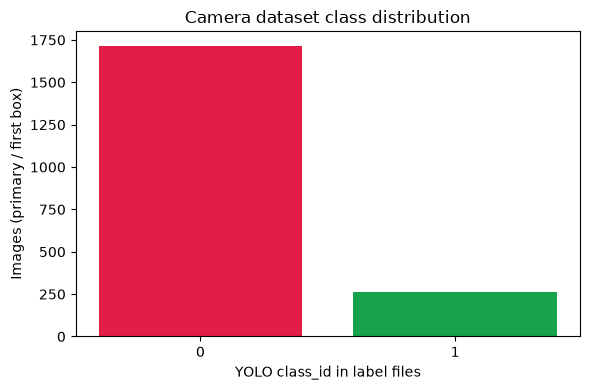

In [7]:
# STEP 7 — Class distribution
rows_for_class = []
for rec in records:
    ids = rec.get("class_ids") or []
    if not ids:
        rows_for_class.append({**rec, "class_id": None})
    elif len(set(ids)) == 1:
        rows_for_class.append({**rec, "class_id": ids[0]})
    else:
        for cid in sorted(set(ids)):
            rows_for_class.append({**rec, "class_id": cid})

class_df = pd.DataFrame(
    [
        {
            "split": r["split"],
            "class_id": r.get("class_id"),
            "n_boxes": r.get("n_boxes", 0),
            "filename": r["filename"],
        }
        for r in records
    ]
)

print("Images by split:")
print(class_df.groupby("split").size())
print("\nImages by primary class_id:")
primary = []
for rec in records:
    ids = rec.get("class_ids") or []
    primary.append(ids[0] if ids else None)
print(pd.Series(primary, name="primary_class").value_counts(dropna=False).sort_index())
print("\nImages per split x primary class:")
tmp = pd.DataFrame({"split": [r["split"] for r in records], "primary_class": primary})
print(pd.crosstab(tmp["split"], tmp["primary_class"]))

fig, ax = plt.subplots(figsize=(6, 4))
vc = pd.Series(primary).value_counts().sort_index()
ax.bar([str(i) for i in vc.index], vc.values, color=["#e11d48", "#16a34a"][: len(vc)])
ax.set_xlabel("YOLO class_id in label files")
ax.set_ylabel("Images (primary / first box)")
ax.set_title("Camera dataset class distribution")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "camera_dataset_analysis" / "class_distribution.png", dpi=140)
plt.show()


In [8]:
# STEP 8 — Are labels YOLO object-detection boxes?
n_valid = sum(1 for r in records if r.get("yolo_valid"))
n_with_boxes = sum(1 for r in records if r.get("n_boxes", 0) > 0)
n_multi = sum(1 for r in records if r.get("n_boxes", 0) > 1)
coord_ok = 0
for rec in records:
    for box in rec.get("boxes") or []:
        if box["yolo_ok"]:
            coord_ok += 1
print("Images with at least one box:", n_with_boxes, "/", len(records))
print("Images with fully valid YOLO rows:", n_valid)
print("Images with >1 box:", n_multi)
print("Valid YOLO box rows:", coord_ok, "of", sum(r.get("n_boxes", 0) for r in records))
print("Format: Ultralytics/YOLOv5–v8 detect txt — class x_center y_center width height, all normalized.")
print("Directory layout train|val|test / images|labels is the standard YOLO detect layout.")
print("Missing data.yaml: YOLO training would need names + nc restored before a clean train run.")
print("labels.cache proves a prior Ultralytics run existed (version 1.0.3) with nc=1, which incorrectly flagged class-1 labels.")
yolo_suitable = n_with_boxes == len(records) and n_valid == len(records)
print("YOLO-suitable annotations:", yolo_suitable)


Images with at least one box: 1979 / 1979
Images with fully valid YOLO rows: 1979
Images with >1 box: 5
Valid YOLO box rows: 1984 of 1984
Format: Ultralytics/YOLOv5–v8 detect txt — class x_center y_center width height, all normalized.
Directory layout train|val|test / images|labels is the standard YOLO detect layout.
Missing data.yaml: YOLO training would need names + nc restored before a clean train run.
labels.cache proves a prior Ultralytics run existed (version 1.0.3) with nc=1, which incorrectly flagged class-1 labels.
YOLO-suitable annotations: True


In [9]:
# STEP 9 — Overlap with the existing 5885-image fundus dataset
meta = pd.read_csv(EXISTING_META)
print("Existing metadata rows:", len(meta), "expected 5885")
for split_name in ("train", "validation", "test"):
    sp = pd.read_csv(SPLIT_DIR / f"{split_name}.csv")
    print(f"  splits_v2/{split_name}.csv:", len(sp))

existing_paths = [Path(p) for p in meta["image_path"].astype(str)]
existing_names = {p.name.lower() for p in existing_paths}
existing_stems = {p.stem.lower() for p in existing_paths}

def strip_roboflow(name: str) -> str:
    n = Path(name).stem.lower()
    if ".rf." in n:
        n = n.split(".rf.")[0]
    for suffix in ("_jpg", "_jpeg", "_png"):
        if n.endswith(suffix):
            n = n[: -len(suffix)]
    return n

camera_stripped = {strip_roboflow(r["filename"]) for r in records}
name_hits = sorted(existing_names & {r["filename"].lower() for r in records})
stem_hits = sorted(existing_stems & camera_stripped)

print("Exact filename matches:", len(name_hits), name_hits[:10])
print("Stem matches after stripping Roboflow hash:", len(stem_hits), stem_hits[:10])

# Content hashes for a definitive overlap check
print("Hashing existing fundus files...")
existing_md5 = {}
missing_existing = 0
for p in existing_paths:
    if not p.exists():
        missing_existing += 1
        continue
    existing_md5[hashlib.md5(p.read_bytes()).hexdigest()] = p.name
print("Hashed existing images:", len(existing_md5), "missing files:", missing_existing)

print("Hashing camera dataset...")
md5_hits = []
for rec in records:
    digest = hashlib.md5(Path(rec["image_path"]).read_bytes()).hexdigest()
    rec["md5"] = digest
    if digest in existing_md5:
        md5_hits.append((rec["filename"], existing_md5[digest]))

print("MD5 content matches:", len(md5_hits))
if md5_hits:
    print(md5_hits[:20])

overlap = {
    "existing_metadata_rows": int(len(meta)),
    "exact_filename_matches": len(name_hits),
    "stripped_stem_matches": len(stem_hits),
    "md5_content_matches": len(md5_hits),
    "filename_match_examples": name_hits[:20],
    "stem_match_examples": stem_hits[:20],
    "md5_match_examples": md5_hits[:20],
}


Existing metadata rows: 5885 expected 5885
  splits_v2/train.csv: 4119
  splits_v2/validation.csv: 883
  splits_v2/test.csv: 883
Exact filename matches: 0 []
Stem matches after stripping Roboflow hash: 102 ['image_0', 'image_1', 'image_10', 'image_103', 'image_104', 'image_105', 'image_106', 'image_107', 'image_11', 'image_110']
Hashing existing fundus files...
Hashed existing images: 5885 missing files: 0
Hashing camera dataset...
MD5 content matches: 0


In [10]:
# STEP 10 — Conclusions, reports, PASS/FAIL
# Class-name conclusion uses only evidence from this folder.
# There is no names mapping file. Visual inspection of boxed regions:
#   class 0 on color image_* and PHOTO-* samples: iris/pupil with milky/opaque lens (cataract appearance)
#   class 1 on image_* and PHOTO-* samples: iris/pupil with a clear iris and dark pupil (normal appearance)
#   i_* files (n=1549) are labeled exclusively class 0; many are grayscale external-eye crops
# Names are therefore: class 0 = cataract (opaque lens / cataract-labeled family), class 1 = normal / clear eye
# with the explicit caveat that data.yaml is missing so names are inferred from pixels + filename families,
# not from an official names: list.

class0_meaning = (
    "Cataract / opaque-lens eye region. Evidence: (a) YOLO class_id 0 in label txt files; "
    "(b) bounding boxes on color image_* and WhatsApp PHOTO-* samples enclose iris/pupil with milky-white lens opacity; "
    "(c) all 1549 i_* files are labeled only class 0. No data.yaml names list is present in this copy."
)
class1_meaning = (
    "Normal / clear-eye region. Evidence: (a) YOLO class_id 1 in label txt files; "
    "(b) bounding boxes on image_* and PHOTO-* samples enclose a clear iris and dark pupil; "
    "(c) Ultralytics labels.cache msgs state 'Label class 1 exceeds dataset class count 1', proving class 1 exists in labels "
    "even though a prior cache was built with nc=1. No data.yaml names list is present in this copy."
)

can_use_for_camera_eye_detection = True
can_train_4class_disease = False

conclusion_c = (
    "YES, with caveats, for a camera-image eye localization / 2-class (cataract vs normal appearance) detector. "
    "Layout is YOLO detect (train/val/test + images/labels + normalized xywh). "
    "Images are external camera/clinical close-ups of the eye, not fundus photographs. "
    "Restore data.yaml (nc: 2 and names) before training. Do not treat this as a generic face/eye-vs-background detector: "
    "almost every image already is an eye close-up."
)
conclusion_d = (
    "NO. It cannot directly train the existing 4-class EfficientNetV2-B0 disease classifier. "
    "That model is validated on retinal fundus images with classes Normal, Cataract, Diabetic Retinopathy, Glaucoma. "
    "This dataset is 2-class external-eye object detection, different imaging modality, and has no DR/glaucoma fundus labels."
)
conclusion_e = (
    "NO overlapping image content. "
    f"MD5 matches={overlap['md5_content_matches']}, exact filename matches={overlap['exact_filename_matches']}. "
    f"{overlap['stripped_stem_matches']} stripped-stem collisions (e.g. image_0) are generic names also used by G1020/ORIGA, not the same pixels."
)

analysis_pass = (
    CAMERA_ROOT.exists()
    and len(records) > 0
    and sorted(class_id_counter) == [0, 1]
    and len(corrupt) == 0
    and overlap["md5_content_matches"] == 0
)

report = {
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "camera_root": str(CAMERA_ROOT),
    "structure": {
        "splits": {s: {
            "images": sum(1 for r in records if r["split"] == s),
            "labels_matched": sum(1 for r in records if r["split"] == s and r["has_label"]),
        } for s in SPLITS},
        "total_images": len(records),
        "config_files_found": [str(p.relative_to(CAMERA_ROOT)) for p in config_files],
        "data_yaml_present": False,
        "ultralytics_cache": cache_meta,
    },
    "class_ids_in_labels": {str(k): int(v) for k, v in sorted(class_id_counter.items())},
    "class_distribution_images_primary": {str(k): int(v) for k, v in Counter(primary).items()},
    "filename_families": {k: {str(a): int(b) for a, b in v.items()} for k, v in family_class.items()},
    "image_properties": {
        "formats": dict(format_counter),
        "aspect_buckets": dict(aspect_buckets),
        "unique_resolutions": len(size_counter),
        "top_resolutions": [{"width": w, "height": h, "count": n} for (w, h), n in size_counter.most_common(10)],
        "width_min_median_max": [int(min(widths)), int(np.median(widths)), int(max(widths))],
        "height_min_median_max": [int(min(heights)), int(np.median(heights)), int(max(heights))],
        "near_grayscale": int(sum(1 for r in readable if r["is_near_grayscale"])),
        "whatsapp_photo_filenames": int(sum(1 for r in records if r["filename"].lower().startswith("photo-"))),
        "corrupt_unreadable": len(corrupt),
    },
    "yolo": {
        "images_with_boxes": n_with_boxes,
        "fully_valid_label_files": n_valid,
        "images_with_multiple_boxes": n_multi,
        "suitable_for_yolo_detect": bool(yolo_suitable),
        "format": "YOLOv5/YOLOv8 detect txt (class xc yc w h normalized)",
    },
    "overlap_with_existing_5885": overlap,
    "conclusions": {
        "A_class_0": class0_meaning,
        "B_class_1": class1_meaning,
        "C_usable_for_camera_eye_detection_stage": can_use_for_camera_eye_detection,
        "C_detail": conclusion_c,
        "D_can_directly_train_4class_disease_classifier": can_train_4class_disease,
        "D_detail": conclusion_d,
        "E_overlap_with_existing_dataset": overlap["md5_content_matches"] > 0,
        "E_detail": conclusion_e,
    },
    "analysis_pass": bool(analysis_pass),
    "next_step": (
        "Obtain or reconstruct data.yaml with nc: 2 and official names for class 0 and class 1 "
        "(this copy has none). Then, if the product still needs a camera-image eye stage, train a separate "
        "YOLO detector on these boxes — do not retrain or mix this data into EfficientNetV2-B0 / the 5885 fundus set."
    ),
}

json_path = REPORTS_DIR / "camera_dataset_analysis.json"
csv_path = REPORTS_DIR / "camera_dataset_analysis.csv"
json_path.write_text(json.dumps(report, indent=2), encoding="utf-8")

csv_fields = [
    "split", "filename", "n_boxes", "class_ids", "primary_class", "yolo_valid",
    "width", "height", "aspect_ratio", "format", "readable", "is_near_grayscale", "md5",
]
with csv_path.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=csv_fields)
    writer.writeheader()
    for rec in records:
        writer.writerow({
            "split": rec["split"],
            "filename": rec["filename"],
            "n_boxes": rec.get("n_boxes", 0),
            "class_ids": " ".join(str(i) for i in rec.get("class_ids") or []),
            "primary_class": (rec.get("class_ids") or [""])[0] if rec.get("class_ids") else "",
            "yolo_valid": rec.get("yolo_valid", False),
            "width": rec.get("width", ""),
            "height": rec.get("height", ""),
            "aspect_ratio": rec.get("aspect_ratio", ""),
            "format": rec.get("format", ""),
            "readable": rec.get("readable", False),
            "is_near_grayscale": rec.get("is_near_grayscale", ""),
            "md5": rec.get("md5", ""),
        })

print("Wrote", json_path)
print("Wrote", csv_path)
print()
print("=" * 72)
print("CONCLUSION A — class 0:", class0_meaning)
print()
print("CONCLUSION B — class 1:", class1_meaning)
print()
print("CONCLUSION C — camera-image eye detection stage:", can_use_for_camera_eye_detection)
print(conclusion_c)
print()
print("CONCLUSION D — train existing 4-class disease classifier:", can_train_4class_disease)
print(conclusion_d)
print()
print("CONCLUSION E — overlap with 5885-image dataset:", overlap["md5_content_matches"] > 0)
print(conclusion_e)
print()
print("ANALYSIS:", "PASS" if analysis_pass else "FAIL")
print("NEXT STEP:", report["next_step"])
print("=" * 72)


Wrote d:\Practice Projects\Disease Detection\reports\camera_dataset_analysis.json
Wrote d:\Practice Projects\Disease Detection\reports\camera_dataset_analysis.csv

CONCLUSION A — class 0: Cataract / opaque-lens eye region. Evidence: (a) YOLO class_id 0 in label txt files; (b) bounding boxes on color image_* and WhatsApp PHOTO-* samples enclose iris/pupil with milky-white lens opacity; (c) all 1549 i_* files are labeled only class 0. No data.yaml names list is present in this copy.

CONCLUSION B — class 1: Normal / clear-eye region. Evidence: (a) YOLO class_id 1 in label txt files; (b) bounding boxes on image_* and PHOTO-* samples enclose a clear iris and dark pupil; (c) Ultralytics labels.cache msgs state 'Label class 1 exceeds dataset class count 1', proving class 1 exists in labels even though a prior cache was built with nc=1. No data.yaml names list is present in this copy.

CONCLUSION C — camera-image eye detection stage: True
YES, with caveats, for a camera-image eye localization